

# Project: Investigate a Dataset - [TMDB Movies]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

I have used the TMDB Movies dataset for this analysis. It contains information about around 10,000 movies, including details such as their ratings, budgets, revenue, and other movie-related information. The dataset includes the following columns: id, imdb_id, budget, revenue, original_title, cast, homepage, director, tagline, keywords, overview, runtime, genres, production_companies, release_date, vote_count, vote_average, release_year, budget_adj, and revenue_adj. These columns provide useful information about each movie, including its financial performance, audience ratings, production details, and other basic characteristics.

### Question(s) for Analysis

We will analyse the dataset to find the answers of the below questions:
1. Does budget predict revenue? (Do bigger-budget movies make more money, or is the relationship weaker than assumed?)
2. Which genres are most profitable?

I'll import the libraries I need, then load the movie data into a table so I can start working with it.

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv('tmdb-movies.csv')

Let's look at the first few rows to see what the data looks like.

In [31]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


<a id='wrangling'></a>
## Data Wrangling

Let's check how many rows and columns the data has.

In [32]:
df.shape

(10866, 21)

Now let's check the data types of each column, and see if any columns have missing values.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

As we can see, some entries are missing. There should be 10,866 entries in each column, but columns such as `imdb_id`, `cast`, `homepage`, `director`, `tagline`, `keywords`, and `production_companies` have fewer than 10,866 entries.

Let's look at some summary statistics, like the minimum, maximum, and average for each numeric column.

In [34]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


Budget, revenue, and runtime show a minimum of 0, which isn't realistic - these are likely missing values. Let's check how many rows are affected, plus check for duplicates.

In [35]:
print("Duplicate rows:", df.duplicated().sum())
print("Rows with budget == 0:", len(df.query('budget == 0')))
print("Rows with revenue == 0:", len(df.query('revenue == 0')))
print("Rows with runtime == 0:", len(df.query('runtime == 0')))

Duplicate rows: 1
Rows with budget == 0: 5696
Rows with revenue == 0: 6016
Rows with runtime == 0: 31


The dataset has very few duplicate rows, but a large number of missing values represented by 0, especially for budget and revenue.

### Data Cleaning

Now let's clean the data - remove duplicate rows, and remove rows where budget or revenue is 0.

In [36]:
def clean_financials(data):
    data = data.drop_duplicates()
    data = data[data['budget'] != 0]
    data = data[data['revenue'] != 0]
    return data.copy()

df_clean = clean_financials(df)

The function clean_financials() cleans the DataFrame by:

Removing duplicate rows.

Removing movies with missing/invalid financial data (budget = 0).

Removing movies with missing/invalid financial data (revenue = 0).

Saving the cleaned data as a new DataFrame (df_clean) without changing the original df.

In [37]:
def format_plot(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

The function format_plot() adds a title and axis labels to a chart. It takes in the chart (ax) along with the title, x-axis label, and y-axis label as text, and applies them to the chart. I'll reuse this function for each visualization below instead of writing the same three lines of formatting code every time.


Let's check how many rows are left after cleaning.

In [38]:
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 10866
Rows after cleaning: 3854


As we can see, the numbers of rows have reduced after cleaning.

<a id='eda'></a>
## Exploratory Data Analysis

### Research Question 1 : Does budget predict revenue? (Do bigger-budget movies make more money, or is the relationship weaker than assumed?)

First, I'll look at budget alone, revenue alone, then compare them together to see if there's a pattern.
X - Axis is budget, Y - Axis is movies

<AxesSubplot: title={'center': 'Distribution of Movie Budgets'}, xlabel='Budget (USD)', ylabel='Number of Movies'>

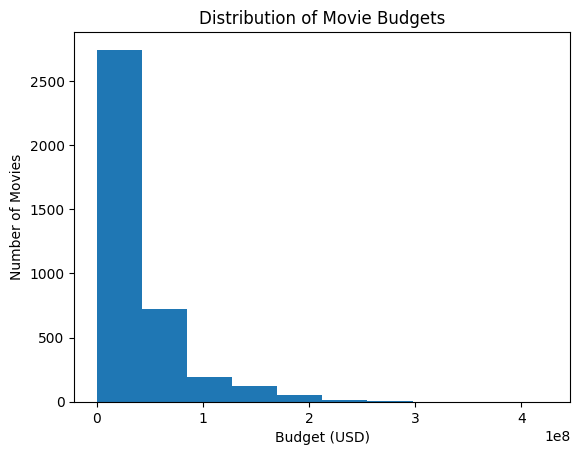

In [39]:
ax = df_clean['budget'].plot(kind='hist')
format_plot(ax, 'Distribution of Movie Budgets', 'Budget (USD)', 'Number of Movies')

Most movies have a small budget. Only a few movies have a very high budget.

Now we will look at the revenue part.
X - Axis is revenue, Y - Axis is movies

<AxesSubplot: title={'center': 'Distribution of Movie Revenue'}, xlabel='Revenue (USD)', ylabel='Number of Movies'>

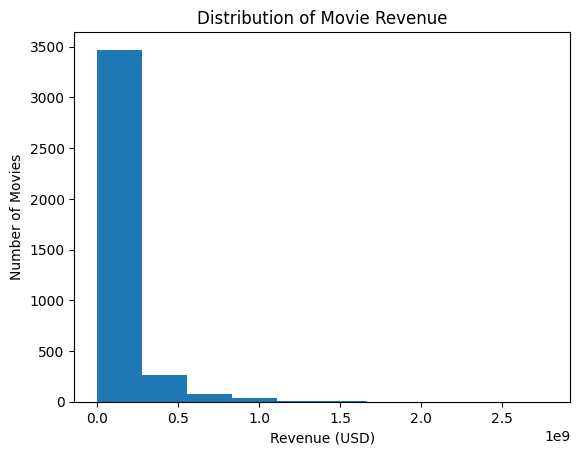

In [40]:
ax = df_clean['revenue'].plot(kind='hist')
format_plot(ax, 'Distribution of Movie Revenue', 'Revenue (USD)', 'Number of Movies')

Same pattern for revenue - most movies earn less, and only a few movies earn a lot.

Now let's look at budget and revenue together to see if there's a relationship between them.

<AxesSubplot: title={'center': 'Budget vs. Revenue'}, xlabel='Budget (USD)', ylabel='Revenue (USD)'>

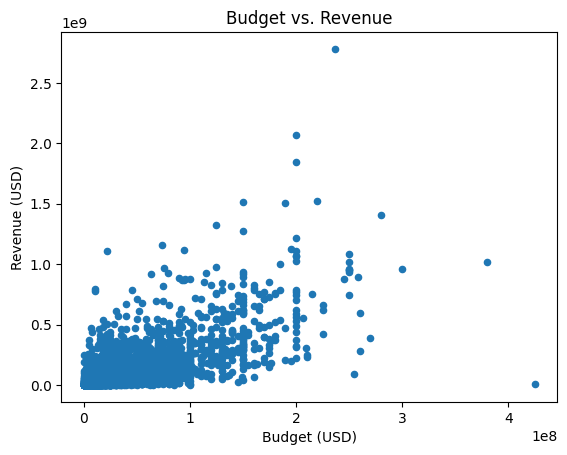

In [41]:
ax = df_clean.plot(kind='scatter', x='budget', y='revenue')
format_plot(ax, 'Budget vs. Revenue', 'Budget (USD)', 'Revenue (USD)')

As budget goes up, revenue also tends to go up. But it's not a perfect pattern - some low-budget movies made a lot of money, and some high-budget movies did not.

Now we will check the correlation between budget and revenue.

In [42]:
budget_revenue_corr = df_clean['budget'].corr(df_clean['revenue'])
print("Correlation between budget and revenue:", budget_revenue_corr)

Correlation between budget and revenue: 0.6885561524636742


Conclusion: Budget and revenue are positively related (about 0.69). This means bigger budgets are often linked to bigger revenue, but it's not guaranteed — other things also affect how much a movie earns.

### Research Question 2 : Which genres are most profitable?

Each movie can have multiple genres stored together in one cell (like "Action|Adventure"). I'll split these apart so I can look at profit by genre.

Creating a copy of cleaned data as df_genre

In [43]:
df_genre = df_clean.copy()

Now changing genres changes from "Action|Adventure" into a list like ['Action', 'Adventure'] by splitting at the | symbol.

In [44]:
df_genre['genres'] = df_genre['genres'].str.split('|')

".explode('genres')" turns a list of genres into separate rows, so ['Action', 'Adventure'] becomes one row for Action and one for Adventure. This lets us analyze each genre separately.

In [45]:
df_genre = df_genre.explode('genres')

Now let's verify it worked, then move on to calculating profit.

In [46]:
df_genre[['original_title', 'genres']].head(10)

,original_title,genres
0,Jurassic World,Action
0,Jurassic World,Adventure
0,Jurassic World,Science Fiction
0,Jurassic World,Thriller
1,Mad Max: Fury Road,Action
1,Mad Max: Fury Road,Adventure
1,Mad Max: Fury Road,Science Fiction
1,Mad Max: Fury Road,Thriller
2,Insurgent,Adventure
2,Insurgent,Science Fiction


The genres are now separated for each movie.

Creating the profit column and checking it.

In [47]:
df_genre['profit'] = df_genre['revenue'] - df_genre['budget']
df_genre['profit']

0        1363528810
0        1363528810
0        1363528810
0        1363528810
1         228436354
            ...    
10835       8000000
10835       8000000
10835       8000000
10848       6885000
10848       6885000
Name: profit, Length: 10303, dtype: int64

Here we can only see the profit, to see profit alongside the title and genre, we select multiple columns instead using double brackets.

In [48]:
df_genre[['original_title', 'genres', 'profit']].head(10)

,original_title,genres,profit
0,Jurassic World,Action,1363528810
0,Jurassic World,Adventure,1363528810
0,Jurassic World,Science Fiction,1363528810
0,Jurassic World,Thriller,1363528810
1,Mad Max: Fury Road,Action,228436354
1,Mad Max: Fury Road,Adventure,228436354
1,Mad Max: Fury Road,Science Fiction,228436354
1,Mad Max: Fury Road,Thriller,228436354
2,Insurgent,Adventure,185238201
2,Insurgent,Science Fiction,185238201


Now that we can see title/genre/profit together, let's answer the actual question: which genres are most profitable on average?

In [49]:
genre_profit = df_genre.groupby('genres')['profit'].mean().sort_values(ascending=False)
genre_profit

genres
Animation          1.801850e+08
Adventure          1.483529e+08
Fantasy            1.475167e+08
Family             1.406744e+08
Science Fiction    1.079463e+08
Action             1.001367e+08
Comedy             6.422751e+07
War                6.377623e+07
Thriller           6.044586e+07
Romance            5.847267e+07
Music              5.688553e+07
Mystery            5.598205e+07
Crime              5.110735e+07
Drama              4.627488e+07
History            4.070002e+07
Horror             3.872150e+07
TV Movie           3.700000e+07
Western            3.457804e+07
Documentary        1.767142e+07
Foreign            1.685289e+06
Name: profit, dtype: float64

Animation, Adventure, Fantasy, and Family lead in average profitability. Animation takes the first place.

We will convert the above results into a bar chart.

<AxesSubplot: title={'center': 'Average Profit by Genre'}, xlabel='Genre', ylabel='Average Profit (USD)'>

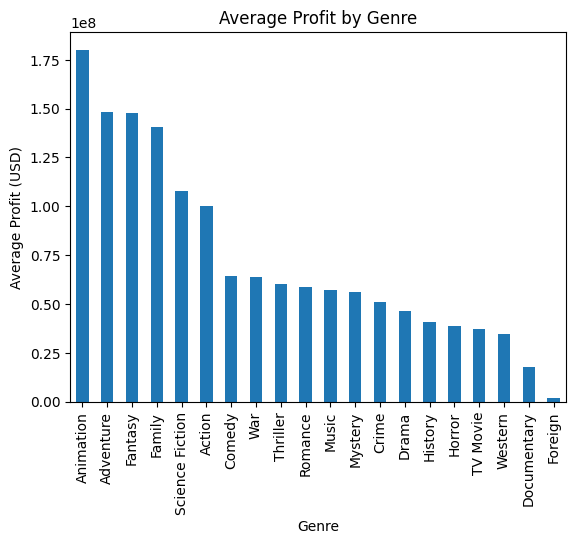

In [50]:
ax = genre_profit.plot(kind='bar')
format_plot(ax, 'Average Profit by Genre', 'Genre', 'Average Profit (USD)')

Animation, Adventure, Fantasy, and Family have the highest average profit, with Animation ranked first showing that these genres tend to be the most financially rewarding for studios to invest in.

<a id='conclusions'></a>
## Conclusions

Question 1: Does budget predict revenue? (Do bigger-budget movies make more money, or is the relationship weaker than assumed?)

Budget and revenue show a moderate-to-strong positive correlation of 0.69, meaning movies with higher budgets tend to also have higher revenue. However, this is only a correlation, not proof that a bigger budget causes higher revenue as other factors were not examined here.

Question 2: Which genres are most profitable?

Animation, Adventure, Fantasy, and Family had the highest average profit among all genres in the cleaned dataset, while Documentary and Foreign films had the lowest. 
